# Three-Judge Comparison

Compare three LLM-as-a-judge evaluation runs over the same dataset.
This notebook aligns samples across all judges, compares mean metrics,
shows pairwise agreement, and highlights where judges disagree most.

In [1]:
import itertools
import json

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from mlflow.tracking import MlflowClient

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

In [2]:
# Config
MLFLOW_TRACKING_URI = "http://localhost:8567"

# Internal labels; human-readable labels are derived from run params.
RUNS = {
    # "judge_a": "53fdfeda71b644028d483906ed9cb406", # 4o-mini
    # "judge_b": "c8da3550a0a145f1aac8805d2ee6c733", # 5.4-mini
    # "judge_c": "38c7e3a1d5b14453a2cdb78089fa7df8", # 5.4

    "judge_a": "c8da3550a0a145f1aac8805d2ee6c733", # 5.4-mini
    "judge_b": "ecf5391da53c4cb292476c43f86b9dd0", # 5.4-mini, temperature 0.0 (04/25/2026, 03:48:47 PM)
    "judge_c": "5779a1c0a0684cbd849df139c9dea9be", # 5.4-mini, temperature 0.0 (04/25/2026, 08:42:47 PM)
}

RAGAS_TABLE_ARTIFACT = "ragas_scores.json"
METRIC_COLS = [
    "faithfulness",
    "context_precision",
    "context_recall",
    "answer_relevance",
    "factual_correctness",
    "factual_correctness_recall",
]
JOIN_KEYS = ["user_input", "subdomain", "question_class"]

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

Tracking URI: http://localhost:8567


In [3]:
def list_artifacts_recursive(run_id: str, path: str = ""):
    items = []
    for art in client.list_artifacts(run_id, path):
        items.append(art.path)
        if art.is_dir:
            items.extend(list_artifacts_recursive(run_id, art.path))
    return items


def normalize_logged_table(json_obj) -> pd.DataFrame:
    if isinstance(json_obj, list):
        return pd.DataFrame(json_obj)
    if isinstance(json_obj, dict):
        if "data" in json_obj and "columns" in json_obj:
            return pd.DataFrame(json_obj["data"], columns=json_obj["columns"])
        return pd.DataFrame(json_obj)
    raise ValueError("Unsupported ragas_scores.json structure")


def load_ragas_table_for_run(run_id: str) -> pd.DataFrame:
    matches = [p for p in list_artifacts_recursive(run_id) if p.endswith(RAGAS_TABLE_ARTIFACT)]
    if not matches:
        raise FileNotFoundError(f"No {RAGAS_TABLE_ARTIFACT} in run {run_id}")
    local_path = client.download_artifacts(run_id, matches[0])
    with open(local_path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    df = normalize_logged_table(payload)
    for col in METRIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def judge_label(info, fallback):
    p = info["params"]
    model = p.get("judge_model") or p.get("judge_llm_model")
    provider = p.get("judge_provider")
    if model and provider:
        return f"{provider}/{model}"
    return model or fallback

## 1. Fetch run metadata and logged means

In [4]:
runs_info = {}
for label, run_id in RUNS.items():
    run = client.get_run(run_id)
    runs_info[label] = {
        "run_id": run_id,
        "params": dict(run.data.params),
        "metrics": dict(run.data.metrics),
        "start_time": pd.to_datetime(run.info.start_time, unit="ms"),
        "status": run.info.status,
    }

JUDGE_LABELS = {label: judge_label(info, label) for label, info in runs_info.items()}
JUDGE_ORDER = list(RUNS.keys())

params_df = pd.DataFrame({JUDGE_LABELS[label]: info["params"] for label, info in runs_info.items()})
display(params_df)

metrics_df = pd.DataFrame({JUDGE_LABELS[label]: info["metrics"] for label, info in runs_info.items()})
metric_order = [m for m in METRIC_COLS if m in metrics_df.index] + [m for m in metrics_df.index if m not in METRIC_COLS]
metrics_df = metrics_df.loc[metric_order]

for left, right in itertools.combinations(JUDGE_ORDER, 2):
    col = f"diff ({JUDGE_LABELS[right]} - {JUDGE_LABELS[left]})"
    metrics_df[col] = metrics_df[JUDGE_LABELS[right]] - metrics_df[JUDGE_LABELS[left]]

metrics_df.round(4)

,openai/gpt-5.4-mini
llm_provider,openai
llm_model,gpt-4o-mini
embedding_provider,ollama
embedding_model,nomic-embed-text
judge_provider,openai
judge_model,gpt-5.4-mini
judge_embedding_provider,ollama
ragas_version,0.4.3
num_samples,20
ragas_metrics,"faithfulness,context_precision,context_recall,..."


,openai/gpt-5.4-mini,diff (openai/gpt-5.4-mini - openai/gpt-5.4-mini)
faithfulness,0.6517,0.0
context_precision,0.5371,0.0
context_recall,0.5917,0.0
answer_relevance,0.7296,0.0
factual_correctness,0.5237,0.0
factual_correctness_recall,0.8200,0.0
rag_phase_runtime_s,0.0007,0.0
eval_phase_runtime_s,1069.4546,0.0
mean_num_retrieved_contexts,10.5000,0.0
total_num_retrieved_contexts,210.0000,0.0


## 2. Load and align per-sample scores

In [5]:
per_run_tables = {}
for label, run_id in RUNS.items():
    df = load_ragas_table_for_run(run_id)
    df["run_label"] = label
    df["judge"] = JUDGE_LABELS[label]
    per_run_tables[label] = df
    print(f"{label} ({JUDGE_LABELS[label]}): {len(df)} rows")

metric_cols_present = [c for c in METRIC_COLS if c in next(iter(per_run_tables.values())).columns]

sample_sets = {
    label: set(map(tuple, df[JOIN_KEYS].fillna("").astype(str).itertuples(index=False, name=None)))
    for label, df in per_run_tables.items()
}
shared_samples = set.intersection(*sample_sets.values())
all_samples = set.union(*sample_sets.values())
print(f"Shared across all judges: {len(shared_samples)}")
print(f"In at least one judge: {len(all_samples)}")
for label in JUDGE_ORDER:
    print(f"Only in {label}: {len(sample_sets[label] - shared_samples)}")

wide = None
for label in JUDGE_ORDER:
    sub = per_run_tables[label][JOIN_KEYS + metric_cols_present].copy()
    sub = sub.rename(columns={c: f"{c}__{label}" for c in metric_cols_present})
    wide = sub if wide is None else wide.merge(sub, on=JOIN_KEYS, how="inner")

for c in metric_cols_present:
    cols = [f"{c}__{label}" for label in JUDGE_ORDER]
    wide[f"{c}__range"] = wide[cols].max(axis=1) - wide[cols].min(axis=1)
    wide[f"{c}__std"] = wide[cols].std(axis=1)

print(f"Aligned rows (inner join across all judges): {len(wide)}")
wide.head()

judge_a (openai/gpt-5.4-mini): 20 rows


judge_b (openai/gpt-5.4-mini): 20 rows


judge_c (openai/gpt-5.4-mini): 20 rows
Shared across all judges: 20
In at least one judge: 20
Only in judge_a: 0
Only in judge_b: 0
Only in judge_c: 0
Aligned rows (inner join across all judges): 20


,user_input,subdomain,question_class,faithfulness__judge_a,context_precision__judge_a,context_recall__judge_a,answer_relevance__judge_a,factual_correctness__judge_a,factual_correctness_recall__judge_a,faithfulness__judge_b,context_precision__judge_b,context_recall__judge_b,answer_relevance__judge_b,factual_correctness__judge_b,factual_correctness_recall__judge_b,faithfulness__judge_c,context_precision__judge_c,context_recall__judge_c,answer_relevance__judge_c,factual_correctness__judge_c,factual_correctness_recall__judge_c,faithfulness__range,faithfulness__std,context_precision__range,context_precision__std,context_recall__range,context_recall__std,answer_relevance__range,answer_relevance__std,factual_correctness__range,factual_correctness__std,factual_correctness_recall__range,factual_correctness_recall__std
0,How many qubits are typically found in a NISQ-...,nisq_constraints_and_qsd_constraints,fact_single,1.000000,0.503268,1.000000,0.960312,0.50,1.00,1.000000,0.521122,1.000000,0.960262,0.50,1.00,1.000000,0.521122,1.000000,0.960262,0.50,1.00,0.000000,0.000000,0.017854,0.010308,0.0,0.00000,0.000051,0.000029,0.00,0.000000,0.00,0.000000
1,What are the primary challenges quantum resear...,nisq_constraints_and_qsd_constraints,summary,0.750000,0.783691,0.666667,0.987341,0.32,0.56,NaN,0.755120,0.666667,0.984872,NaN,0.50,NaN,0.788650,0.666667,0.982886,NaN,NaN,0.000000,NaN,0.033531,0.018098,0.0,0.00000,0.004455,0.002232,0.00,NaN,0.06,0.042426
2,Why does the accuracy of my results typically ...,nisq_constraints_and_qsd_constraints,reasoning,0.466667,1.000000,1.000000,0.948860,0.56,0.67,0.444444,1.000000,1.000000,0.948799,0.45,0.75,0.631579,1.000000,1.000000,0.949396,0.35,0.83,0.187135,0.102233,0.000000,0.000000,0.0,0.00000,0.000597,0.000328,0.21,0.105040,0.16,0.080000
3,What is the specific hourly cost for accessing...,nisq_constraints_and_qsd_constraints,unanswerable,1.000000,0.000000,1.000000,0.000000,1.00,1.00,1.000000,0.000000,0.000000,0.000000,1.00,1.00,1.000000,0.000000,1.000000,0.000000,1.00,1.00,0.000000,0.000000,0.000000,0.000000,1.0,0.57735,0.000000,0.000000,0.00,0.000000,0.00,0.000000
4,What is the fundamental unit of organization f...,experiment_tracking_fundamentals,fact_single,0.500000,0.666667,1.000000,0.987112,0.33,1.00,0.500000,0.666667,1.000000,0.987123,0.33,1.00,0.500000,0.666667,1.000000,0.987123,0.40,1.00,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000011,0.000006,0.07,0.040415,0.00,0.000000


## 3. Overall metric comparison and pairwise agreement

In [6]:
overall_rows = []
agreement_rows = []

for c in metric_cols_present:
    row = {"metric": c}
    metric_values = []
    for label in JUDGE_ORDER:
        col = f"{c}__{label}"
        m = wide[col].mean()
        row[JUDGE_LABELS[label]] = m
        metric_values.append(m)

    pairwise_mae = []
    for left, right in itertools.combinations(JUDGE_ORDER, 2):
        left_col = f"{c}__{left}"
        right_col = f"{c}__{right}"
        a = wide[left_col]
        b = wide[right_col]
        mask = a.notna() & b.notna()
        a_, b_ = a[mask], b[mask]
        pairwise_mae.append((a_ - b_).abs().mean() if len(a_) else np.nan)
        agreement_rows.append(
            {
                "metric": c,
                "judge_left": JUDGE_LABELS[left],
                "judge_right": JUDGE_LABELS[right],
                "n": int(mask.sum()),
                "pearson": a_.corr(b_, method="pearson") if len(a_) > 1 else np.nan,
                "spearman": a_.corr(b_, method="spearman") if len(a_) > 1 else np.nan,
                "mae": (a_ - b_).abs().mean() if len(a_) else np.nan,
                "exact_agreement": np.isclose(a_, b_).mean() if len(a_) else np.nan,
            }
        )

    row["range_of_means"] = np.nanmax(metric_values) - np.nanmin(metric_values)
    row["mean_pairwise_mae"] = np.nanmean(pairwise_mae)
    row["mean_sample_range"] = wide[f"{c}__range"].mean()
    overall_rows.append(row)

overall = pd.DataFrame(overall_rows).set_index("metric").round(4)
agreement_df = pd.DataFrame(agreement_rows).round(4)

display(overall)
display(agreement_df)

,openai/gpt-5.4-mini,range_of_means,mean_pairwise_mae,mean_sample_range
metric,,,,
faithfulness,0.6517,0.1063,0.0695,0.0901
context_precision,0.5371,0.0225,0.0222,0.0333
context_recall,0.5917,0.1250,0.1833,0.2750
answer_relevance,0.7296,0.0471,0.0323,0.0484
factual_correctness,0.5237,0.0342,0.0458,0.0640
factual_correctness_recall,0.8200,0.0580,0.0459,0.0645


,metric,judge_left,judge_right,n,pearson,spearman,mae,exact_agreement
0,faithfulness,openai/gpt-5.4-mini,openai/gpt-5.4-mini,15,0.9534,0.9426,0.0650,0.5333
1,faithfulness,openai/gpt-5.4-mini,openai/gpt-5.4-mini,16,0.9450,0.9058,0.0637,0.5625
2,faithfulness,openai/gpt-5.4-mini,openai/gpt-5.4-mini,16,0.9111,0.8855,0.0797,0.6250
3,context_precision,openai/gpt-5.4-mini,openai/gpt-5.4-mini,20,0.9959,0.9858,0.0138,0.7500
4,context_precision,openai/gpt-5.4-mini,openai/gpt-5.4-mini,20,0.9891,0.9659,0.0285,0.6000
5,context_precision,openai/gpt-5.4-mini,openai/gpt-5.4-mini,20,0.9913,0.9679,0.0243,0.7000
6,context_recall,openai/gpt-5.4-mini,openai/gpt-5.4-mini,20,0.4470,0.4878,0.2000,0.8000
7,context_recall,openai/gpt-5.4-mini,openai/gpt-5.4-mini,20,0.7518,0.7281,0.1250,0.8500
8,context_recall,openai/gpt-5.4-mini,openai/gpt-5.4-mini,20,0.4933,0.4808,0.2250,0.7500
9,answer_relevance,openai/gpt-5.4-mini,openai/gpt-5.4-mini,20,1.0000,0.9940,0.0015,0.2000


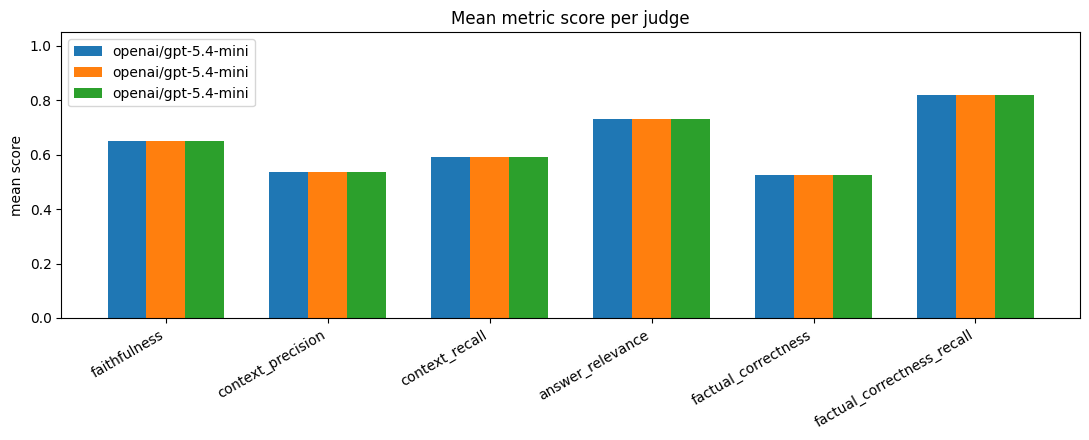

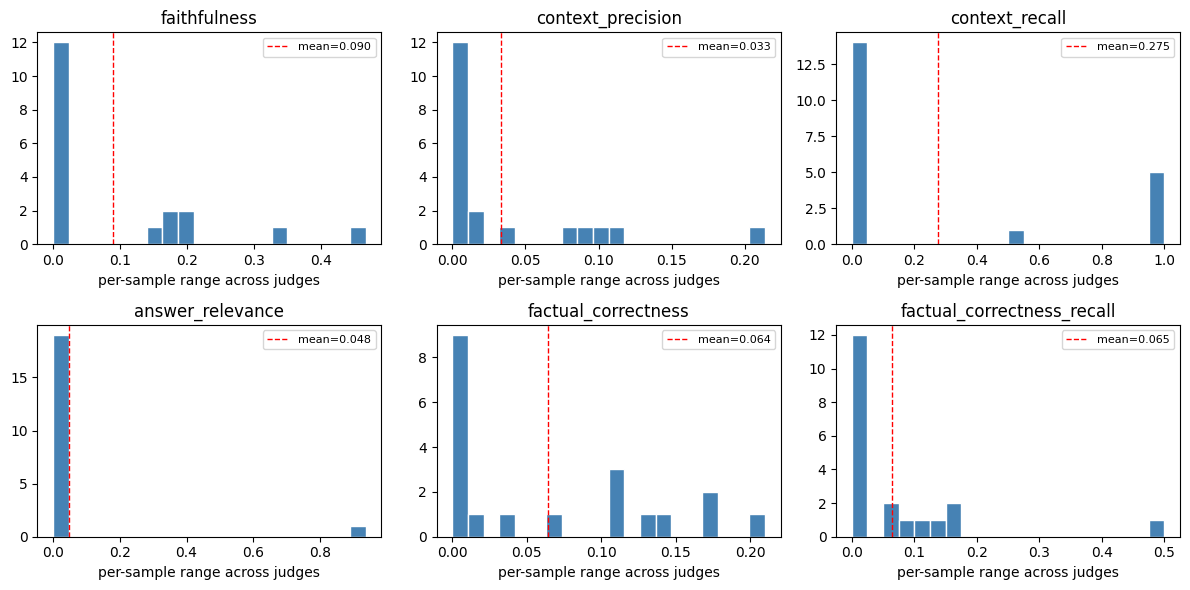

In [7]:
x = np.arange(len(metric_cols_present))
bar_w = 0.24
offsets = np.linspace(-(len(JUDGE_ORDER) - 1) / 2, (len(JUDGE_ORDER) - 1) / 2, len(JUDGE_ORDER)) * bar_w

fig, ax = plt.subplots(figsize=(11, 4.5))
for offset, label in zip(offsets, JUDGE_ORDER):
    ax.bar(x + offset, [overall.loc[c, JUDGE_LABELS[label]] for c in metric_cols_present], bar_w, label=JUDGE_LABELS[label])

ax.set_xticks(x)
ax.set_xticklabels(metric_cols_present, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("mean score")
ax.set_title("Mean metric score per judge")
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, int(np.ceil(len(metric_cols_present) / 2)), figsize=(12, 6))
axes = np.array(axes).ravel()
for i, c in enumerate(metric_cols_present):
    ax = axes[i]
    vals = wide[f"{c}__range"].dropna()
    ax.hist(vals, bins=20, color="steelblue", edgecolor="white")
    ax.axvline(vals.mean(), color="red", linestyle="--", linewidth=1, label=f"mean={vals.mean():.3f}")
    ax.set_title(c)
    ax.set_xlabel("per-sample range across judges")
    ax.legend(fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

## 4. Largest disagreements and group-level spread

In [8]:
TOP_N = 10
for c in metric_cols_present:
    judge_cols = [f"{c}__{label}" for label in JUDGE_ORDER]
    display_cols = JOIN_KEYS + judge_cols + [f"{c}__range", f"{c}__std"]
    sub = wide[display_cols].sort_values(f"{c}__range", ascending=False).head(TOP_N)
    if sub[f"{c}__range"].max() == 0:
        continue
    renamed = sub.rename(columns={f"{c}__{label}": JUDGE_LABELS[label] for label in JUDGE_ORDER})
    print(f"\n=== Top {TOP_N} disagreements: {c} ===")
    print(renamed.to_string(index=False, max_colwidth=80))


def group_compare(df_wide: pd.DataFrame, group_col: str) -> pd.DataFrame:
    rows = []
    for group_val, sub in df_wide.groupby(group_col, dropna=False):
        for c in metric_cols_present:
            judge_means = [sub[f"{c}__{label}"].mean() for label in JUDGE_ORDER]
            row = {
                group_col: group_val,
                "metric": c,
                "n": len(sub),
                "range_of_means": np.nanmax(judge_means) - np.nanmin(judge_means),
            }
            for label in JUDGE_ORDER:
                row[JUDGE_LABELS[label]] = sub[f"{c}__{label}"].mean()
            rows.append(row)
    return pd.DataFrame(rows)


by_qclass = group_compare(wide, "question_class")
by_subdomain = group_compare(wide, "subdomain")

display(by_qclass.pivot(index="question_class", columns="metric", values="range_of_means").round(4))
display(by_subdomain.pivot(index="subdomain", columns="metric", values="range_of_means").round(4))


=== Top 10 disagreements: faithfulness ===
                                                                      user_input                                                  subdomain question_class  openai/gpt-5.4-mini  openai/gpt-5.4-mini  openai/gpt-5.4-mini  faithfulness__range  faithfulness__std
Can you summarize what kind of data the MLflow Tracking API actually captures...                                        mlflow_tracking_api        summary             0.400000             0.200000             0.666667             0.466667           0.234126
  Can you give me an overview of the four main categories in the QProv taxonomy?                                  qprov_provenance_taxonomy        summary             0.700000             0.400000             0.750000             0.350000           0.189297
My circuit results are really noisy; does logging T2 times help me figure out... qiskit-specific_experiment_tracking_using_mlflow_and_qprov      reasoning             0.800000       

metric,answer_relevance,context_precision,context_recall,factual_correctness,factual_correctness_recall,faithfulness
question_class,,,,,,
fact_single,0.0008,0.0514,0.0,0.0140,0.0000,0.0333
reasoning,0.0010,0.0594,0.5,0.0285,0.1275,0.1395
summary,0.0019,0.0088,0.0,0.1145,0.0645,0.2722
unanswerable,0.1873,0.0000,0.2,0.0000,0.0000,0.0048


metric,answer_relevance,context_precision,context_recall,factual_correctness,factual_correctness_recall,faithfulness
subdomain,,,,,,
experiment_tracking_fundamentals,0.0000,0.0281,0.375,0.0625,0.0250,0.0877
mlflow_tracking_api,0.0007,0.0234,0.250,0.0450,0.0700,0.3379
nisq_constraints_and_qsd_constraints,0.0010,0.0084,0.250,0.0550,0.1358,0.0730
qiskit-specific_experiment_tracking_using_mlflow_and_qprov,0.2341,0.0250,0.000,0.0750,0.1250,0.0472
qprov_provenance_taxonomy,0.0011,0.0745,0.250,0.0742,0.0575,0.1167


In [9]:
# Uncomment to export tables.
# wide.to_csv("judge_3way_per_sample.csv", index=False)
# overall.to_csv("judge_3way_overall.csv")
# agreement_df.to_csv("judge_3way_pairwise_agreement.csv", index=False)
# by_qclass.to_csv("judge_3way_by_qclass.csv", index=False)
# by_subdomain.to_csv("judge_3way_by_subdomain.csv", index=False)
print("Done.")

Done.
